<a href="https://colab.research.google.com/github/mv24aat/Predictive-Qty-Recommendation-System-FYP/blob/main/Copy_of_FYP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/merged_patients.xls')

print(f'Shape: {df.shape}')
df.head()

Shape: (19802, 29)


,Patient_ID,Age,Sex,Weight_kg,Height_cm,Ethnicity,Hypertension,Diabetes,Chronic_Kidney_Disease,Heart_Failure,...,Diet_VitK_Intake,Final_Stable_Dose_mg,INR_Stabilization_Days,Adverse_Event,TTR_pct,CYP2C9_pcyp3,VKORC1_AA,On_Amiodarone,Alcohol_Score,VitK_Score
0,P000001,64,F,88,194,Caucasian,0,0,0,0,...,Low,2.4,5,NaN,66.8,1.0,0.0,0.0,2.0,0.0
1,P000002,50,M,101,175,Other,1,0,0,0,...,Low,3.8,8,NaN,72.4,0.0,0.0,0.0,2.0,0.0
2,P000003,66,F,85,162,Asian,0,0,0,0,...,Medium,3.1,7,NaN,58.0,0.0,0.0,0.0,3.0,1.0
3,P000004,58,M,83,178,African American,1,0,0,0,...,Low,5.4,6,NaN,77.9,0.0,0.0,0.0,1.0,0.0
4,P000005,61,F,75,194,Caucasian,1,0,0,1,...,High,6.6,7,NaN,70.6,0.0,0.0,0.0,1.0,2.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19802 entries, 0 to 19801
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Patient_ID              19802 non-null  object 
 1   Age                     19802 non-null  int64  
 2   Sex                     19802 non-null  object 
 3   Weight_kg               19802 non-null  int64  
 4   Height_cm               19802 non-null  int64  
 5   Ethnicity               19802 non-null  object 
 6   Hypertension            19802 non-null  int64  
 7   Diabetes                19802 non-null  int64  
 8   Chronic_Kidney_Disease  19802 non-null  int64  
 9   Heart_Failure           19802 non-null  int64  
 10  Amiodarone              19802 non-null  int64  
 11  Antibiotics             19802 non-null  int64  
 12  Aspirin                 19802 non-null  int64  
 13  Statins                 19802 non-null  int64  
 14  CYP2C9                  19802 non-null

In [ ]:
num_cols = df.select_dtypes(include='number').columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

print('Numeric columns:', num_cols)
print('\nCategorical columns:', cat_cols)

Numeric columns: ['Age', 'Weight_kg', 'Height_cm', 'Hypertension', 'Diabetes', 'Chronic_Kidney_Disease', 'Heart_Failure', 'Amiodarone', 'Antibiotics', 'Aspirin', 'Statins', 'Final_Stable_Dose_mg', 'INR_Stabilization_Days', 'TTR_pct', 'CYP2C9_pcyp3', 'VKORC1_AA', 'On_Amiodarone', 'Alcohol_Score', 'VitK_Score']

Categorical columns: ['Patient_ID', 'Sex', 'Ethnicity', 'CYP2C9', 'VKORC1', 'CYP4F2', 'Alcohol_Intake', 'Smoking_Status', 'Diet_VitK_Intake', 'Adverse_Event']


In [ ]:
df[num_cols].describe().round(2)

,Age,Weight_kg,Height_cm,Hypertension,Diabetes,Chronic_Kidney_Disease,Heart_Failure,Amiodarone,Antibiotics,Aspirin,Statins,Final_Stable_Dose_mg,INR_Stabilization_Days,TTR_pct,CYP2C9_pcyp3,VKORC1_AA,On_Amiodarone,Alcohol_Score,VitK_Score
count,19802.00,19802.00,19802.00,19802.00,19802.0,19802.0,19802.0,19802.0,19802.0,19802.00,19802.00,19802.00,19802.00,19801.00,19801.00,19801.00,19801.0,19801.00,19801.00
mean,67.46,74.54,169.44,0.40,0.2,0.2,0.2,0.1,0.1,0.30,0.30,3.30,7.73,70.13,0.26,0.14,0.1,0.96,0.80
std,9.87,14.64,9.73,0.49,0.4,0.4,0.4,0.3,0.3,0.46,0.46,1.62,2.82,10.60,0.44,0.35,0.3,0.93,0.75
min,40.00,45.00,150.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,1.00,0.00,30.00,0.00,0.00,0.0,0.00,0.00
25%,61.00,64.00,163.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,2.00,6.00,63.10,0.00,0.00,0.0,0.00,0.00
50%,67.00,74.00,169.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,3.00,8.00,70.10,0.00,0.00,0.0,1.00,1.00
75%,74.00,84.00,176.00,1.00,0.0,0.0,0.0,0.0,0.0,1.00,1.00,4.40,9.00,77.40,1.00,0.00,0.0,2.00,1.00
max,90.00,120.00,200.00,1.00,1.0,1.0,1.0,1.0,1.0,1.00,1.00,10.10,20.00,95.00,1.00,1.00,1.0,3.00,2.00


In [ ]:
for col in ['Sex', 'Ethnicity', 'CYP2C9', 'VKORC1', 'CYP4F2',
            'Alcohol_Intake', 'Smoking_Status', 'Diet_VitK_Intake',
            'Adverse_Event']:
    print(f'\n--- {col} ---')
    print(df[col].value_counts(dropna=False))



--- Sex ---
Sex
M    10792
F     9010
Name: count, dtype: int64

--- Ethnicity ---
Ethnicity
Caucasian           8929
Asian               3911
African American    3009
Hispanic            2965
Other                988
Name: count, dtype: int64

--- CYP2C9 ---
CYP2C9
*1/*1    10130
*1/*2     3606
*1/*3     3448
*2/*3     1159
*2/*2      976
*3/*3      483
Name: count, dtype: int64

--- VKORC1 ---
VKORC1
G/G    9719
A/G    7265
A/A    2818
Name: count, dtype: int64

--- CYP4F2 ---
CYP4F2
C/C    11902
C/T     5893
T/T     2007
Name: count, dtype: int64

--- Alcohol_Intake ---
Alcohol_Intake
NaN         7860
Light       5839
Moderate    5045
Heavy       1058
Name: count, dtype: int64

--- Smoking_Status ---
Smoking_Status
Non-smoker       11790
Former Smoker     5082
Smoker            2930
Name: count, dtype: int64

--- Diet_VitK_Intake ---
Diet_VitK_Intake
Medium    7942
Low       7937
High      3923
Name: count, dtype: int64

--- Adverse_Event ---
Adverse_Event
NaN         16559
Bleedin

                Missing count  Missing %
Alcohol_Intake           7860       39.7
Adverse_Event           16559       83.6
TTR_pct                     1        0.0
CYP2C9_pcyp3                1        0.0
VKORC1_AA                   1        0.0
On_Amiodarone               1        0.0
Alcohol_Score               1        0.0
VitK_Score                  1        0.0


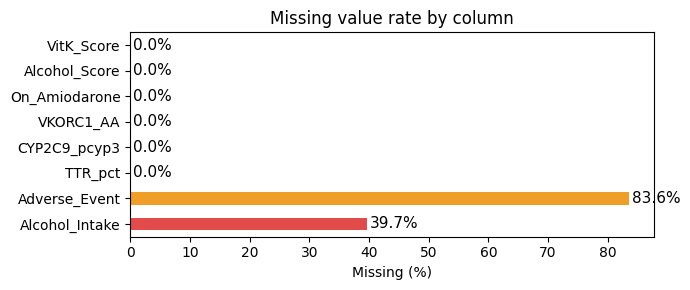

In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'Missing count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing count'] > 0]
print(missing_df)

# Plot
fig, ax = plt.subplots(figsize=(7, 3))
missing_df['Missing %'].plot(kind='barh', ax=ax, color=['#E24B4A', '#EF9F27'])
ax.set_xlabel('Missing (%)')
ax.set_title('Missing value rate by column')
for i, v in enumerate(missing_df['Missing %']):
    ax.text(v + 0.5, i, f'{v}%', va='center', fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
df['Adverse_Event_bin'] = df['Adverse_Event'].notna().astype(int)
print('Adverse events (recoded):')
print(df['Adverse_Event_bin'].value_counts())

Adverse events (recoded):
Adverse_Event_bin
0    16559
1     3243
Name: count, dtype: int64


In [ ]:
df['Adverse_Event'] = df['Adverse_Event'].fillna('No Event')
df['Alcohol_Intake'] = df['Alcohol_Intake'].fillna('Non-drinker')

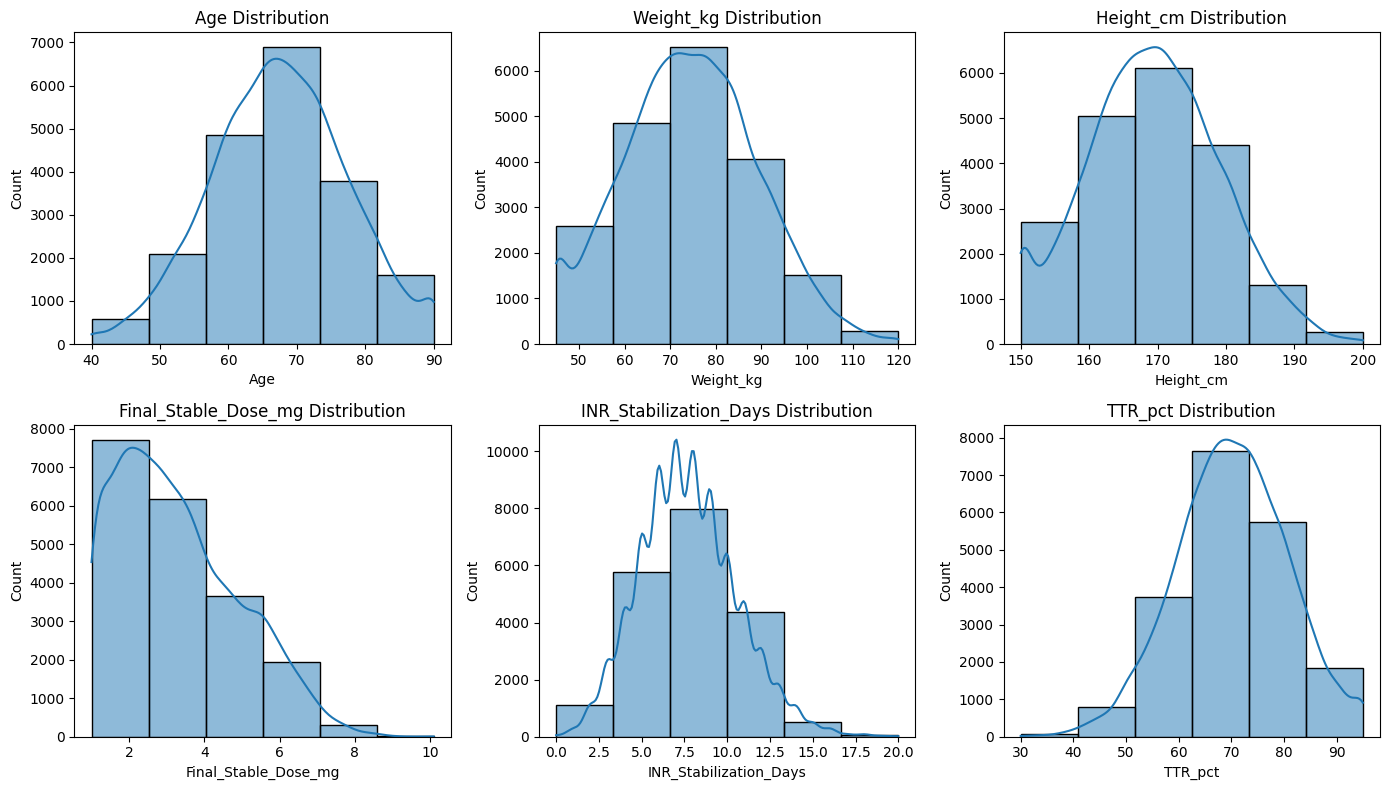

In [ ]:
bins = 6

fig, ax = plt.subplots(2, 3, figsize=(14, 8))

sns.histplot(df['Age'], bins=bins, kde=True, ax=ax[0, 0])
ax[0, 0].set_title('Age Distribution')

sns.histplot(df['Weight_kg'], bins=bins, kde=True, ax=ax[0, 1])
ax[0, 1].set_title('Weight_kg Distribution')

sns.histplot(df['Height_cm'], bins=bins, kde=True, ax=ax[0, 2])
ax[0, 2].set_title('Height_cm Distribution')

sns.histplot(df['Final_Stable_Dose_mg'], bins=bins, kde=True, ax=ax[1, 0])
ax[1, 0].set_title('Final_Stable_Dose_mg Distribution')

sns.histplot(df['INR_Stabilization_Days'], bins=bins, kde=True, ax=ax[1, 1])
ax[1, 1].set_title('INR_Stabilization_Days Distribution')

sns.histplot(df['TTR_pct'], bins=bins, kde=True, ax=ax[1, 2])
ax[1, 2].set_title('TTR_pct Distribution')

plt.tight_layout()
plt.show()

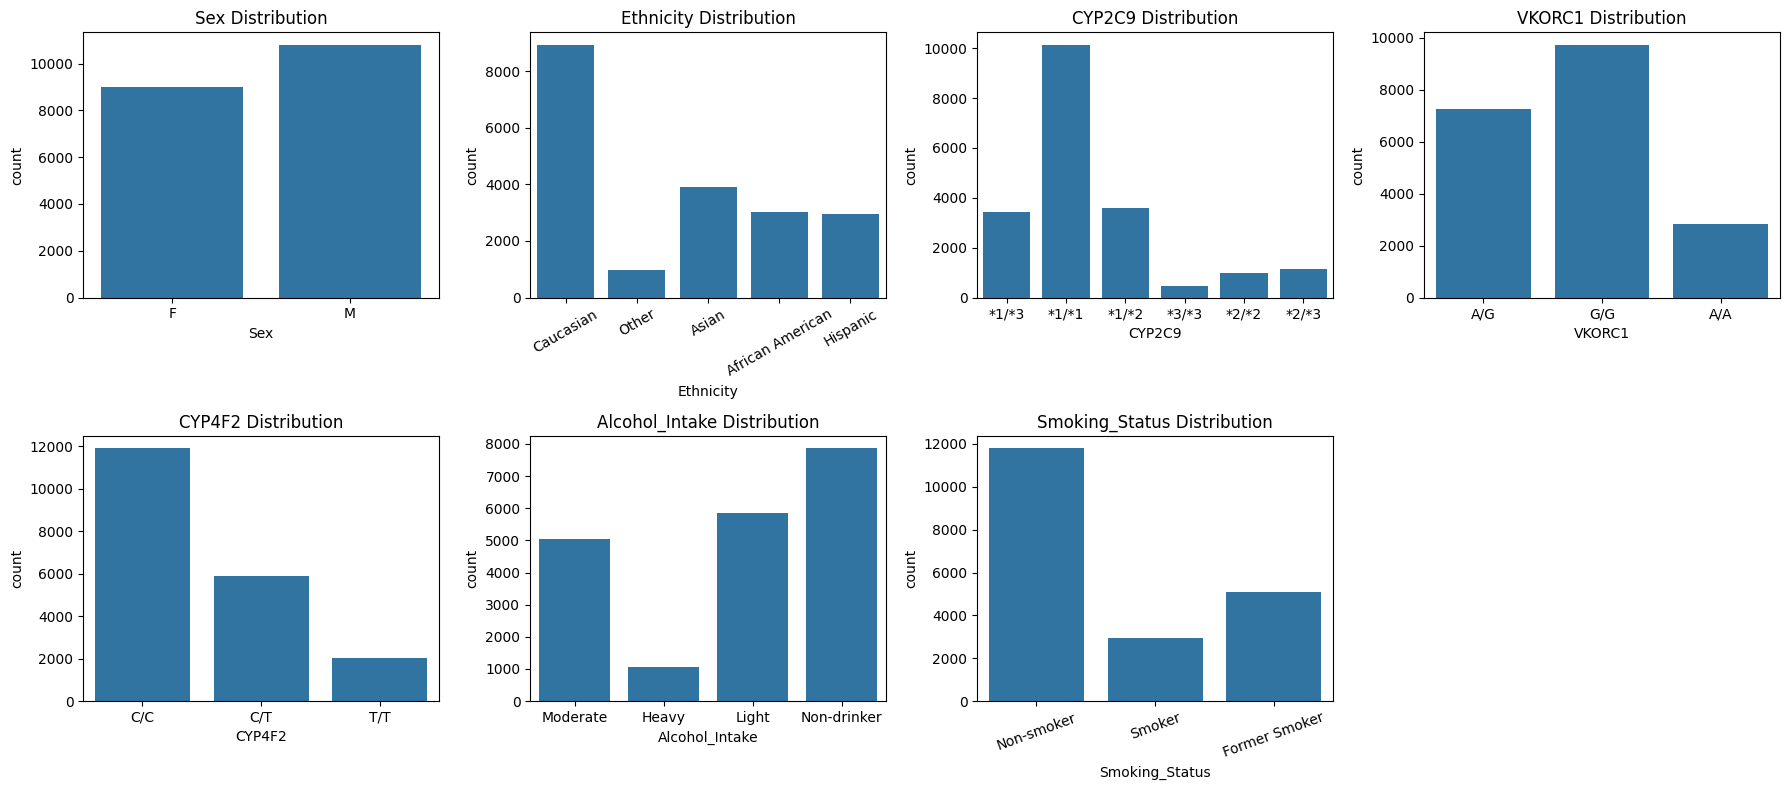

In [ ]:
# Create a 2x4 grid of subplots to fit 7 categorical columns
fig, ax = plt.subplots(2, 4, figsize=(18, 8))

# Plot the count distribution of 'Sex'
sns.countplot(data=df, x='Sex', ax=ax[0, 0])
ax[0, 0].set_title('Sex Distribution')

# Plot the count distribution of 'Ethnicity'
sns.countplot(data=df, x='Ethnicity', ax=ax[0, 1])
ax[0, 1].set_title('Ethnicity Distribution')
ax[0, 1].tick_params(axis='x', rotation=30)

# Plot the count distribution of 'CYP2C9'
sns.countplot(data=df, x='CYP2C9', ax=ax[0, 2])
ax[0, 2].set_title('CYP2C9 Distribution')

# Plot the count distribution of 'VKORC1'
sns.countplot(data=df, x='VKORC1', ax=ax[0, 3])
ax[0, 3].set_title('VKORC1 Distribution')

# Plot the count distribution of 'CYP4F2'
sns.countplot(data=df, x='CYP4F2', ax=ax[1, 0])
ax[1, 0].set_title('CYP4F2 Distribution')

# Plot the count distribution of 'Alcohol_Intake'
sns.countplot(data=df, x='Alcohol_Intake', ax=ax[1, 1])
ax[1, 1].set_title('Alcohol_Intake Distribution')

# Plot the count distribution of 'Smoking_Status'
sns.countplot(data=df, x='Smoking_Status', ax=ax[1, 2])
ax[1, 2].set_title('Smoking_Status Distribution')
ax[1, 2].tick_params(axis='x', rotation=20)

# Hide the unused last subplot
ax[1, 3].set_visible(False)

# Adjust the layout to avoid overlap of plot elements
plt.tight_layout()

# Display the plot
plt.show()


In [ ]:
# Loop through the list of genes and print the normalized value counts for each
for gene in ['CYP2C9', 'VKORC1', 'CYP4F2']:
    print(f'\n{gene} Distribution:\n', df[gene].value_counts(normalize=True))


CYP2C9 Distribution:
 CYP2C9
*1/*1    0.511564
*1/*2    0.182103
*1/*3    0.174124
*2/*3    0.058529
*2/*2    0.049288
*3/*3    0.024391
Name: proportion, dtype: float64

VKORC1 Distribution:
 VKORC1
G/G    0.490809
A/G    0.366882
A/A    0.142309
Name: proportion, dtype: float64

CYP4F2 Distribution:
 CYP4F2
C/C    0.601050
C/T    0.297596
T/T    0.101353
Name: proportion, dtype: float64


In [ ]:
display('Alcohol Intake:', df['Alcohol_Intake'].value_counts(normalize=True))

'Alcohol Intake:'

,proportion
Alcohol_Intake,
Non-drinker,0.396930
Light,0.294869
Moderate,0.254772
Heavy,0.053429


In [ ]:
display('Adverse Events (Percentage):', df['Adverse_Event'].value_counts(normalize=True))
display('Adverse Events (Count):', df['Adverse_Event'].value_counts())

'Adverse Events (Percentage):'

,proportion
Adverse_Event,
No Event,0.836229
Bleeding,0.094182
Clotting,0.069589


'Adverse Events (Count):'

,count
Adverse_Event,
No Event,16559
Bleeding,1865
Clotting,1378


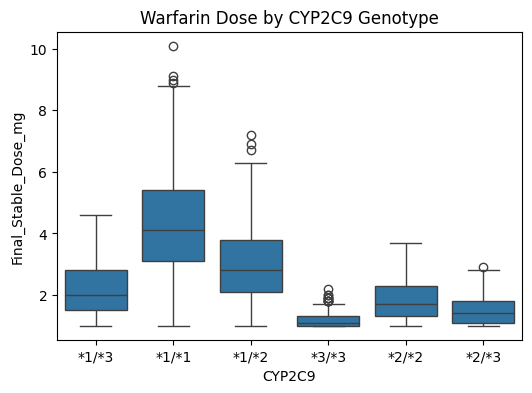

In [ ]:
plt.figure(figsize=(6, 4))

# Plot the boxplot using Seaborn
sns.boxplot(data=df, x='CYP2C9', y='Final_Stable_Dose_mg')
plt.title('Warfarin Dose by CYP2C9 Genotype')
plt.show()

In [ ]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 84.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 67.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 66.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.3/121.3 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.

In [ ]:
import mlflow
import sklearn
import mlflow.sklearn

In [ ]:
pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.9 MB/s eta 0:00:00


In [ ]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from category_encoders import OneHotEncoder

In [ ]:
df.columns

Index(['Patient_ID', 'Age', 'Sex', 'Weight_kg', 'Height_cm', 'Ethnicity',
       'Hypertension', 'Diabetes', 'Chronic_Kidney_Disease', 'Heart_Failure',
       'Amiodarone', 'Antibiotics', 'Aspirin', 'Statins', 'CYP2C9', 'VKORC1',
       'CYP4F2', 'Alcohol_Intake', 'Smoking_Status', 'Diet_VitK_Intake',
       'Final_Stable_Dose_mg', 'INR_Stabilization_Days', 'Adverse_Event',
       'TTR_pct', 'CYP2C9_pcyp3', 'VKORC1_AA', 'On_Amiodarone',
       'Alcohol_Score', 'VitK_Score', 'Adverse_Event_bin'],
      dtype='object')

In [ ]:
features = [
    'Age', 'Sex', 'Weight_kg', 'Height_cm', 'Ethnicity',
    'On_Amiodarone', 'Alcohol_Score', 'VitK_Score'
]

X = df[features]
y = df['Final_Stable_Dose_mg']

In [ ]:
X.head()

,Age,Sex,Weight_kg,Height_cm,Ethnicity,On_Amiodarone,Alcohol_Score,VitK_Score
0,64,F,88,194,Caucasian,0.0,2.0,0.0
1,50,M,101,175,Other,0.0,2.0,0.0
2,66,F,85,162,Asian,0.0,3.0,1.0
3,58,M,83,178,African American,0.0,1.0,0.0
4,61,F,75,194,Caucasian,0.0,1.0,2.0


In [ ]:
from sklearn.pipeline import Pipeline

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = Pipeline([
            ('ohe', OneHotEncoder(use_cat_names=True)),
            ('dt', DecisionTreeRegressor(random_state=42))])
model.fit(X_train, y_train)

Pipeline(steps=[('ohe',
                 OneHotEncoder(cols=['Sex', 'Ethnicity'], use_cat_names=True)),
                ('dt', DecisionTreeRegressor(random_state=42))])

In [ ]:
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

In [ ]:
mlflow.log_params(model.named_steps['dt'].get_params())
mlflow.log_metrics({"mae": mae, "rmse": rmse, "r2": r2})


2026/07/23 20:50:52 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/23 20:50:52 INFO mlflow.store.db.utils: Updating database tables


In [ ]:
mlflow.sklearn.log_model(model, 'model', serialization_format='cloudpickle')

2026/07/23 20:51:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/23 20:51:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [ ]:
engineered_df = df.copy()

engineered_df["BMI"] = engineered_df["Weight_kg"] / ((engineered_df["Height_cm"] / 100) ** 2)

comorbs = ["Hypertension", "Diabetes", "Chronic_Kidney_Disease", "Heart_Failure"]
engineered_df["Comorbidity_Burden"] = engineered_df[comorbs].sum(axis=1)

meds = ["Amiodarone", "Antibiotics", "Aspirin", "Statins"]
engineered_df["Polypharmacy_Index"] = engineered_df[meds].sum(axis=1)

In [ ]:
engineered_df.columns
test_check = engineered_df[['Weight_kg', 'Height_cm', 'BMI']]
test_check.corr()

,Weight_kg,Height_cm,BMI
Weight_kg,1.000000,0.005477,0.857176
Height_cm,0.005477,1.000000,-0.497724
BMI,0.857176,-0.497724,1.000000


In [ ]:
engineered_features = ['Age', 'Sex', 'BMI', 'Weight_kg', 'Height_cm', 'Ethnicity',
                       'Alcohol_Intake', 'Smoking_Status', 'Diet_VitK_Intake',
                       'CYP2C9', 'VKORC1', 'CYP4F2',
                       'On_Amiodarone', 'Comorbidity_Burden', 'Polypharmacy_Index']

In [ ]:
print(engineered_features)

['Age', 'Sex', 'BMI', 'Weight_kg', 'Height_cm', 'Ethnicity', 'Alcohol_Intake', 'Smoking_Status', 'Diet_VitK_Intake', 'CYP2C9', 'VKORC1', 'CYP4F2', 'On_Amiodarone', 'Comorbidity_Burden', 'Polypharmacy_Index']


In [ ]:
X_eng = engineered_df[engineered_features].copy()
y_eng = engineered_df['Final_Stable_Dose_mg']

# Impute missing numerical values before splitting
# These columns were identified as having 1 NaN each in the original df and carried over
for col in ['On_Amiodarone', 'Alcohol_Score', 'VitK_Score']:
    if col in X_eng.columns:
        X_eng[col] = X_eng[col].fillna(X_eng[col].median())

X_train, X_test, y_train, y_test = train_test_split(X_eng, y_eng, test_size=0.2, random_state=42)
ohe = OneHotEncoder(use_cat_names=True)
X_train_encoded = ohe.fit_transform(X_train)
X_test_encoded = ohe.transform(X_test)

In [ ]:
X_train_encoded.columns

Index(['Age', 'Sex_M', 'Sex_F', 'BMI', 'Weight_kg', 'Height_cm',
       'Ethnicity_Asian', 'Ethnicity_Caucasian', 'Ethnicity_African American',
       'Ethnicity_Hispanic', 'Ethnicity_Other', 'Alcohol_Intake_Light',
       'Alcohol_Intake_Heavy', 'Alcohol_Intake_Non-drinker',
       'Alcohol_Intake_Moderate', 'Smoking_Status_Non-smoker',
       'Smoking_Status_Smoker', 'Smoking_Status_Former Smoker',
       'Diet_VitK_Intake_Medium', 'Diet_VitK_Intake_Low',
       'Diet_VitK_Intake_High', 'CYP2C9_*1/*3', 'CYP2C9_*1/*1', 'CYP2C9_*1/*2',
       'CYP2C9_*2/*2', 'CYP2C9_*2/*3', 'CYP2C9_*3/*3', 'VKORC1_G/G',
       'VKORC1_A/A', 'VKORC1_A/G', 'CYP4F2_C/C', 'CYP4F2_C/T', 'CYP4F2_T/T',
       'On_Amiodarone', 'Comorbidity_Burden', 'Polypharmacy_Index'],
      dtype='object')

In [ ]:
mlflow.end_run()

In [ ]:
with mlflow.start_run(run_name='DecisionTree_Engineered'):
    model = DecisionTreeRegressor(random_state=42)
    model.fit(X_train_encoded, y_train)
    y_pred = model.predict(X_test_encoded)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    mlflow.log_params(model.get_params())
    mlflow.log_metrics({"mae": mae, "rmse": rmse, "r2": r2})
    mlflow. sklearn.log_model(model, 'model')

2026/07/23 20:51:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [ ]:
with mlflow.start_run(run_name='ExtraTree_Engineered'):


    model = ExtraTreesRegressor(random_state=42, n_estimators=300, max_depth=None)
    model.fit(X_train_encoded, y_train)


    y_pred = model.predict(X_test_encoded)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    mlflow.log_params(model.get_params())


    mlflow.log_metrics({"mae": mae, "rmse": rmse, "r2": r2})

    mlflow.sklearn.log_model(model, 'model')

2026/07/23 20:52:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [ ]:
run_name = 'ExtraTree_Engineered'
run = mlflow.search_runs(filter_string=f"tags.mlflow.runName = '{run_name}'")
model_uri = f"runs:/{run.run_id[0]}/model"
model_name = 'Genexa_Warfarin_Dosing'
mlflow.register_model(model_uri=model_uri, name=model_name)
genexa_model = mlflow.sklearn.load_model("models:/Genexa_Warfarin_Dosing/1")


Successfully registered model 'Genexa_Warfarin_Dosing'.
2026/07/23 20:52:56 WARNING mlflow.tracking._model_registry.fluent: Run with id 990c59f798f44663a99f94aab15f0ee4 has no artifacts at artifact path 'model', registering model based on models:/m-48c87e193aae44f4b7e7aee501ea66d7 instead
Created version '1' of model 'Genexa_Warfarin_Dosing'.


<Axes: ylabel='Model'>

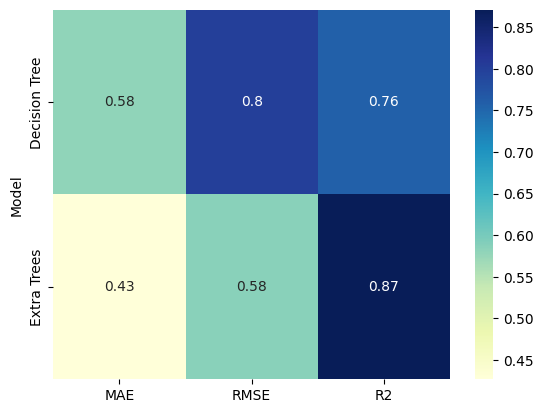

In [ ]:
dt_run = mlflow.search_runs(filter_string="tags.mlflow.runName = 'DecisionTree_Engineered'").iloc[0]
mae_dt = dt_run['metrics.mae']
rmse_dt = dt_run['metrics.rmse']
r2_dt = dt_run['metrics.r2']

et_run = mlflow.search_runs(filter_string="tags.mlflow.runName = 'ExtraTree_Engineered'").iloc[0]
mae_et = et_run['metrics.mae']
rmse_et = et_run['metrics.rmse']
r2_et = et_run['metrics.r2']

results = pd.DataFrame({
    "Model":["Decision Tree","Extra Trees"],
    "MAE":[mae_dt,mae_et],
    "RMSE":[rmse_dt,rmse_et],
    "R2":[r2_dt,r2_et]
})

sns.heatmap(
    results.set_index("Model"),
    annot=True,
    cmap="YlGnBu"
)

In [ ]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import ExtraTreesRegressor
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [ ]:
dt_param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_leaf": [1, 2, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

dt_search = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=dt_param_grid,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
)
dt_search.fit(X_train_encoded, y_train)

print("Best Decision Tree params:", dt_search.best_params_)
print("Best CV MAE:", -dt_search.best_score_)

Best Decision Tree params: {'max_depth': 10, 'min_samples_leaf': 20, 'min_samples_split': 2}
Best CV MAE: 0.41914597189860936


In [ ]:
# Refit best model, evaluate on the held-out test set
best_dt = dt_search.best_estimator_
y_pred_dt = best_dt.predict(X_test_encoded)
mae_dt_tuned = mean_absolute_error(y_test, y_pred_dt)
rmse_dt_tuned = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt_tuned = r2_score(y_test, y_pred_dt)

with mlflow.start_run(run_name="DecisionTree_Tuned"):
    mlflow.log_params(dt_search.best_params_)
    mlflow.log_metrics({
        "mae": mae_dt_tuned, "rmse": rmse_dt_tuned, "r2": r2_dt_tuned,
        "cv_mae": -dt_search.best_score_,
    })
    mlflow.sklearn.log_model(best_dt, "model")


2026/07/23 20:53:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [ ]:
import pandas as pd
from sklearn.model_selection import RandomizedSearchCV
from scipy import sparse
from sklearn.impute import SimpleImputer


imputer = SimpleImputer(strategy='constant', fill_value=0)

# Temporarily store original X_train_encoded and X_test_encoded if they are sparse
original_X_train_encoded = X_train_encoded
original_X_test_encoded = X_test_encoded

# where X_train_encoded might already be a sparse matrix from a previous run
if sparse.issparse(original_X_train_encoded):
    # Assuming 'ohe' (OneHotEncoder) from QkRiaFrucaRF is in scope and its state is preserved
    feature_names = ohe.get_feature_names_out()
    X_train_encoded_for_imputation = pd.DataFrame(original_X_train_encoded.toarray(), columns=feature_names)
    X_test_encoded_for_imputation = pd.DataFrame(original_X_test_encoded.toarray(), columns=feature_names)
else:
    # If it's already a DataFrame (e.g., first run after QkRiaFrucaRF)
    X_train_encoded_for_imputation = original_X_train_encoded
    X_test_encoded_for_imputation = original_X_test_encoded

# Perform imputation on the dense DataFrames
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train_encoded_for_imputation), columns=X_train_encoded_for_imputation.columns)
X_test_imputed = pd.DataFrame(imputer.transform(X_test_encoded_for_imputation), columns=X_test_encoded_for_imputation.columns)

# Convert to sparse matrix using the imputed DataFrames
X_train_encoded = sparse.csr_matrix(X_train_imputed.values)
X_test_encoded = sparse.csr_matrix(X_test_imputed.values)

In [ ]:
et_param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", "log2"],
}



In [ ]:
et_search = RandomizedSearchCV(
    estimator=ExtraTreesRegressor(random_state=42, n_jobs=1),
    param_distributions= et_param_grid,
    n_iter=20,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=2,
    pre_dispatch="2*n_jobs",
    verbose=2,
    random_state=42,
    return_train_score=True,
)


In [ ]:
et_search.fit(X_train_encoded, y_train)



Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=ExtraTreesRegressor(n_jobs=1, random_state=42),
                   n_iter=20, n_jobs=2,
                   param_distributions={'max_depth': [None, 10, 20],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 5],
                                        'n_estimators': [50, 100, 200]},
                   random_state=42, return_train_score=True,
                   scoring='neg_mean_absolute_error', verbose=2)

In [ ]:
print("Best Extra Trees params (from search):", et_search.best_params_)
print("Best CV MAE:", -et_search.best_score_)

Best Extra Trees params (from search): {'n_estimators': 200, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}
Best CV MAE: 0.42358864133411817


In [ ]:
final_et_params = {**et_search.best_params_, "n_estimators": 300}
best_et = ExtraTreesRegressor(random_state=42, n_jobs=-1, **final_et_params)
best_et.fit(X_train_encoded, y_train)

y_pred_et = best_et.predict(X_test_encoded)
mae_et_tuned = mean_absolute_error(y_test, y_pred_et)
rmse_et_tuned = np.sqrt(mean_squared_error(y_test, y_pred_et))
r2_et_tuned = r2_score(y_test, y_pred_et)

with mlflow.start_run(run_name="ExtraTree_Tuned"):
    mlflow.log_params(final_et_params)
    mlflow.log_metrics({
        "mae": mae_et_tuned, "rmse": rmse_et_tuned, "r2": r2_et_tuned,
        "cv_mae_at_search_size": -et_search.best_score_,
    })
    mlflow.sklearn.log_model(best_et, "model")

2026/07/23 21:44:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [ ]:
# Comparison table: baseline vs tuned
comparison = pd.DataFrame({
    "Model": ["Decision Tree (default)", "Decision Tree (tuned)",
              "Extra Trees (default, n=300)", "Extra Trees (tuned)"],
    "MAE": [mae_dt, mae_dt_tuned, mae_et, mae_et_tuned],
    "RMSE": [rmse_dt, rmse_dt_tuned, rmse_et, rmse_et_tuned],
    "R2": [r2_dt, r2_dt_tuned, r2_et, r2_et_tuned],
})
print(comparison)

                          Model       MAE      RMSE        R2
0       Decision Tree (default)  0.580573  0.801515  0.757803
1         Decision Tree (tuned)  0.412925  0.565983  0.879232
2  Extra Trees (default, n=300)  0.426617  0.584746  0.871092
3           Extra Trees (tuned)  0.420713  0.572521  0.876426


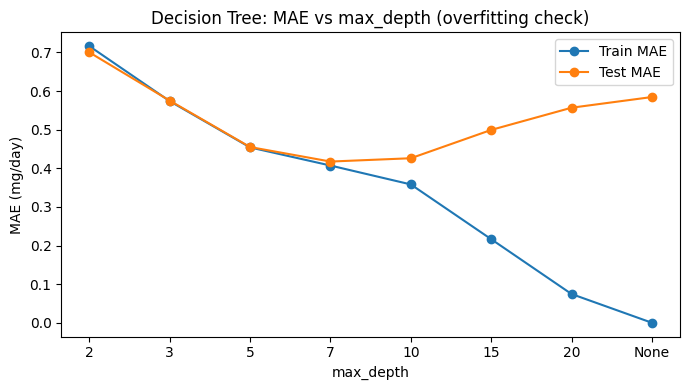

In [ ]:
# Validation curve evidence — MAE vs max_depth
depths_to_plot = [2, 3, 5, 7, 10, 15, 20, None]
cv_mae_by_depth = []
train_mae_by_depth = []

for d in depths_to_plot:
    tree = DecisionTreeRegressor(max_depth=d, random_state=42)
    tree.fit(X_train_encoded, y_train)
    train_pred = tree.predict(X_train_encoded)
    test_pred = tree.predict(X_test_encoded)
    train_mae_by_depth.append(mean_absolute_error(y_train, train_pred))
    cv_mae_by_depth.append(mean_absolute_error(y_test, test_pred))

depth_labels = [str(d) if d is not None else "None" for d in depths_to_plot]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(depth_labels, train_mae_by_depth, marker="o", label="Train MAE")
ax.plot(depth_labels, cv_mae_by_depth, marker="o", label="Test MAE")
ax.set_xlabel("max_depth")
ax.set_ylabel("MAE (mg/day)")
ax.set_title("Decision Tree: MAE vs max_depth (overfitting check)")
ax.legend()
plt.tight_layout()
plt.show()

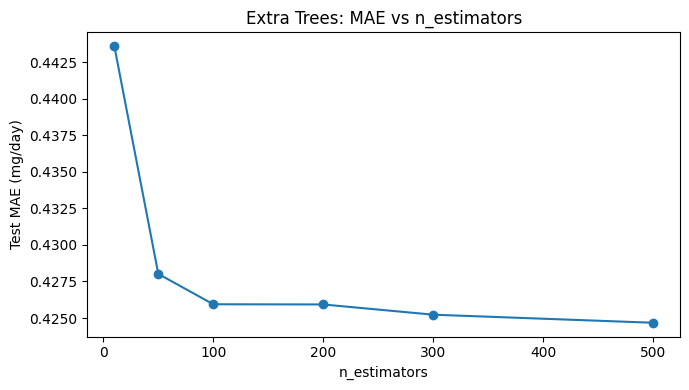

In [ ]:

# Same idea for Extra Trees: MAE vs n_estimators, to justify the final
# ensemble size rather than just picking 300 arbitrarily.
n_est_to_plot = [10, 50, 100, 200, 300, 500]
cv_mae_by_n = []
for n in n_est_to_plot:
    et = ExtraTreesRegressor(n_estimators=n, random_state=42, n_jobs=-1)
    et.fit(X_train_encoded, y_train)
    pred = et.predict(X_test_encoded)
    cv_mae_by_n.append(mean_absolute_error(y_test, pred))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(n_est_to_plot, cv_mae_by_n, marker="o")
ax.set_xlabel("n_estimators")
ax.set_ylabel("Test MAE (mg/day)")
ax.set_title("Extra Trees: MAE vs n_estimators")
plt.tight_layout()
plt.show()

In [ ]:
pip install lime

In [ ]:
import lime
from lime.lime_tabular import LimeTabularExplainer

explainer = LimeTabularExplainer(
    training_data=X_train_encoded.values,
    feature_names=X_train_encoded.columns,
    class_names=['Final_Stable_Dose_mg'],
    mode='regression'
)

instance = X_test_encoded.iloc[5].values.reshape(1, -1)
explanation = explainer.explain_instance(instance[0], genexa_model.predict)
explanation.show_in_notebook()

In [ ]:
et_search.fit(X_train_encoded, y_train)

print("Best Extra Trees params:", et_search.best_params_)
print("Best CV MAE:", -et_search.best_score_)

In [ ]:
!pip install gradio

In [ ]:
import os
import json
from typing import Dict, List, Tuple
import pandas as pd
import gradio as gr
import category_encoders as ce

# Configuration
# =========================
MLFLOW_TRACKING_URI = os.getenv("MLFLOW_TRACKING_URI", "http://127.0.0.1:5000")
MODEL_NAME = os.getenv("MODEL_NAME", "Genexa_Warfarin_Dosing")
MODEL_VERSION = os.getenv("MODEL_VERSION", "1")  # or "Production"

DOSE_MIN, DOSE_MAX = 1.0, 10.0
DOSE_STEP = 0.5

In [ ]:
import subprocess
import time
import os

# Start MLflow UI in the background
# The default port for MLflow UI is 5000
# We redirect stdout and stderr to /dev/null to keep the output clean
mlflow_process = subprocess.Popen(["mlflow", "ui", "--host", "0.0.0.0", "--port", "5000"],
                                  stdout=subprocess.DEVNULL,
                                  stderr=subprocess.DEVNULL,
                                  preexec_fn=os.setsid)

print(f"MLflow UI started in the background on port 5000. PID: {mlflow_process.pid}")
print("Waiting for MLflow UI to start (10 seconds)...")
time.sleep(10) # Give it some time to start
print("MLflow UI should now be running. Please re-run the cell with the error and subsequent cells.")

In [ ]:
FALLBACK_TRAINED_COLUMNS = [
    "Age", "BMI", "Weight_kg", "Height_cm",
    "Sex_F", "Sex_M",
    "Ethnicity_African American", "Ethnicity_Asian", "Ethnicity_Caucasian", "Ethnicity_Hispanic", "Ethnicity_Other",
    "Alcohol_Intake_Light", "Alcohol_Intake_Moderate", "Alcohol_Intake_Heavy", "Alcohol_Intake_nan",
    "Smoking_Status_Former Smoker", "Smoking_Status_Non-smoker", "Smoking_Status_Smoker",
    "Diet_VitK_Intake_High", "Diet_VitK_Intake_Medium", "Diet_VitK_Intake_Low",
    "CYP2C9_*1/*1", "CYP2C9_*1/*2", "CYP2C9_*1/*3", "CYP2C9_*2/*2", "CYP2C9_*2/*3", "CYP2C9_*3/*3",
    "VKORC1_A/A", "VKORC1_A/G", "VKORC1_G/G",
    "CYP4F2_C/C", "CYP4F2_C/T", "CYP4F2_T/T",
    "On_Amiodarone",
    "Comorbidity_Burden",
    "Polypharamcy_index", "Polypharamcy_Index", "Polypharmacy_Index",
]

In [ ]:
CAT_SPECS = {
    "Sex": ["F", "M"],
    "Ethnicity": ["African American", "Asian", "Caucasian", "Hispanic", "Other"],
    "Alcohol_Intake": ["None", "Light", "Moderate", "Heavy"],
    "Diet_VitK_Intake": ["High", "Medium", "Low"],
    "Smoking_Status": ["Former Smoker", "Non-smoker", "Smoker"],
    "CYP2C9": ["*1/*1", "*1/*2", "*1/*3", "*2/*2", "*2/*3", "*3/*3"],
    "VKORC1": ["A/A", "A/G", "G/G"],
    "CYP4F2": ["C/C", "C/T", "T/T"],
}

In [ ]:
CATEGORICAL_COLS = [
    "Sex", "Ethnicity", "Alcohol_Intake", "Diet_VitK_Intake",
    "Smoking_Status", "CYP2C9", "VKORC1", "CYP4F2",
]

GENE_DEFAULTS = {"CYP2C9": "*1/*1", "VKORC1": "G/G", "CYP4F2": "C/C"}
COMORBS = ["Hypertension", "Diabetes", "Chronic_Kidney_Disease", "Heart_Failure"]
MEDS = ["Amiodarone", "Antibiotics", "Aspirin", "Statins"]

In [ ]:
def clip_and_round(dose: float, step: float = DOSE_STEP) -> float:
    dose = float(np.clip(dose, DOSE_MIN, DOSE_MAX))
    return round(step * round(dose / step), 2)


def ensure_genes(payload: Dict) -> Dict:
    fixed = payload.copy()
    for g, dflt in GENE_DEFAULTS.items():
        if fixed.get(g) in [None, "", "NA", "Unknown"]:
            fixed[g] = dflt
    return fixed

In [ ]:
def engineer_single(example: Dict) -> pd.DataFrame:
    ex = ensure_genes(example)
    row = {
        "Age": ex.get("Age"),
        "Weight_kg": ex.get("Weight_kg"),
        "Height_cm": ex.get("Height_cm"),
        "Sex": ex.get("Sex"),
        "Ethnicity": ex.get("Ethnicity"),
        "Alcohol_Intake": ex.get("Alcohol_Intake"),
        "Diet_VitK_Intake": ex.get("Diet_VitK_Intake"),
        "Smoking_Status": ex.get("Smoking_Status"),
        "CYP2C9": ex.get("CYP2C9"),
        "VKORC1": ex.get("VKORC1"),
        "CYP4F2": ex.get("CYP4F2"),
        "On_Amiodarone": int(ex.get("Amiodarone", 0) or ex.get("On_Amiodarone", 0)),
    }
    for c in COMORBS:
        row[c] = int(ex.get(c, 0))
    for m in MEDS:
        row[m] = int(ex.get(m, 0))

    df = pd.DataFrame([row])

    for col, cats in CAT_SPECS.items():
          if col in df.columns:
            df[col] = pd.Categorical(df[col], categories=cats, ordered=False)

    df["BMI"] = df["Weight_kg"] / ((df["Height_cm"] / 100.0) ** 2)
    df["Comorbidity_Burden"] = df[COMORBS].sum(axis=1)
    df["Polypharmacy_Index"] = df[MEDS].sum(axis=1)
    df["Polypharamcy_Index"] = df["Polypharmacy_Index"]
    df["Polypharamcy_index"] = df["Polypharmacy_Index"]

    engineered_cols = [
        "Age", "Weight_kg", "Height_cm", "Sex", "Ethnicity",
        "Alcohol_Intake", "Diet_VitK_Intake", "Smoking_Status",
        "CYP2C9", "VKORC1", "CYP4F2", "On_Amiodarone",
        "BMI", "Comorbidity_Burden",
        "Polypharmacy_Index", "Polypharamcy_Index", "Polypharamcy_index",
    ]
    return df[engineered_cols]

In [ ]:
def load_trained_columns(model) -> List[str]:
    if os.path.exists("trained_columns.json"):
        try:
            with open("trained_columns.json", "r") as f:
                cols = json.load(f)
            if isinstance(cols, list) and len(cols) > 0:
                return cols
        except Exception:
            pass
    try:
        cols = list(model.feature_names_in_)
        if len(cols) > 0:
            return cols
    except Exception:
        pass
    return FALLBACK_TRAINED_COLUMNS

In [ ]:
def to_model_matrix(df_one: pd.DataFrame, trained_columns: List[str]) -> pd.DataFrame:
    enc = ce.OneHotEncoder(
        cols=CATEGORICAL_COLS,
        use_cat_names=True,
        handle_unknown="ignore",
        handle_missing="value"
    )
    X = enc.fit_transform(df_one)
    X = X.reindex(columns=trained_columns, fill_value=0)
    return X

In [ ]:
def engineer_single(example: Dict) -> pd.DataFrame:
    ex = ensure_genes(example)
    row = {
        "Age": ex.get("Age"),
        "Weight_kg": ex.get("Weight_kg"),
        "Height_cm": ex.get("Height_cm"),
        "Sex": ex.get("Sex"),
        "Ethnicity": ex.get("Ethnicity"),
        "Alcohol_Intake": ex.get("Alcohol_Intake"),
        "Diet_VitK_Intake": ex.get("Diet_VitK_Intake"),
        "Smoking_Status": ex.get("Smoking_Status"),
        "CYP2C9": ex.get("CYP2C9"),
        "VKORC1": ex.get("VKORC1"),
        "CYP4F2": ex.get("CYP4F2"),
        "On_Amiodarone": int(ex.get("Amiodarone", 0) or ex.get("On_Amiodarone", 0)),
    }
    for c in COMORBS:
        row[c] = int(ex.get(c, 0))
    for m in MEDS:
        row[m] = int(ex.get(m, 0))

    df = pd.DataFrame([row])

    for col, cats in CAT_SPECS.items():
        if col in df.columns:
            df[col] = pd.Categorical(df[col], categories=cats, ordered=False)

    df["BMI"] = df["Weight_kg"] / ((df["Height_cm"] / 100.0) ** 2)
    df["Comorbidity_Burden"] = df[COMORBS].sum(axis=1)
    df["Polypharmacy_Index"] = df[MEDS].sum(axis=1)
    df["Polypharamcy_Index"] = df["Polypharmacy_Index"]
    df["Polypharamcy_index"] = df["Polypharmacy_Index"]

    engineered_cols = [
        "Age", "Weight_kg", "Height_cm", "Sex", "Ethnicity",
        "Alcohol_Intake", "Diet_VitK_Intake", "Smoking_Status",
        "CYP2C9", "VKORC1", "CYP4F2", "On_Amiodarone",
        "BMI", "Comorbidity_Burden",
        "Polypharmacy_Index", "Polypharamcy_Index", "Polypharamcy_index",
    ]
    return df[engineered_cols]


def load_trained_columns(model) -> List[str]:
    if os.path.exists("trained_columns.json"):
        try:
            with open("trained_columns.json", "r") as f:
                cols = json.load(f)
            if isinstance(cols, list) and len(cols) > 0:
                return cols
        except Exception:
            pass
    try:
        cols = list(model.feature_names_in_)
        if len(cols) > 0:
            return cols
    except Exception:
        pass
    return FALLBACK_TRAINED_COLUMNS

def to_model_matrix(df_one: pd.DataFrame, trained_columns: List[str]) -> pd.DataFrame:
    enc = ce.OneHotEncoder(
        cols=CATEGORICAL_COLS,
        use_cat_names=True,
        handle_unknown="ignore",
        handle_missing="value"
    )
    X = enc.fit_transform(df_one)
    X = X.reindex(columns=trained_columns, fill_value=0)
    return X
# =========================
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
MODEL_URI = f"models:/{MODEL_NAME}/{MODEL_VERSION}"
champion_model = mlflow.sklearn.load_model(MODEL_URI)
TRAINED_COLUMNS = load_trained_columns(champion_model)


# =========================
# Gradio predict function
# =========================
def predict_fn(
    Age, Weight_kg, Height_cm, Sex, Ethnicity,
    Alcohol_Intake, Diet_VitK_Intake, Smoking_Status,
    CYP2C9, VKORC1, CYP4F2,
    Hypertension, Diabetes, Chronic_Kidney_Disease, Heart_Failure,
    Amiodarone, Antibiotics, Aspirin, Statins
):
    payload = {
        "Age": Age, "Weight_kg": Weight_kg, "Height_cm": Height_cm,
        "Sex": Sex, "Ethnicity": Ethnicity,
        "Alcohol_Intake": Alcohol_Intake, "Diet_VitK_Intake": Diet_VitK_Intake, "Smoking_Status": Smoking_Status,
        "CYP2C9": CYP2C9, "VKORC1": VKORC1, "CYP4F2": CYP4F2,
        "Hypertension": int(Hypertension), "Diabetes": int(Diabetes),
        "Chronic_Kidney_Disease": int(Chronic_Kidney_Disease), "Heart_Failure": int(Heart_Failure),
        "Amiodarone": int(Amiodarone), "Antibiotics": int(Antibiotics),
        "Aspirin": int(Aspirin), "Statins": int(Statins),
    }

    df_one = engineer_single(payload)
    X_one = to_model_matrix(df_one, TRAINED_COLUMNS)

    raw_pred = float(champion_model.predict(X_one)[0])
    dose = clip_and_round(raw_pred, step=DOSE_STEP)
    return f"{dose} mg/day", f"{raw_pred:.3f} mg/day", df_one, X_one


# =========================
# Build Gradio UI (inline)
# =========================
with gr.Blocks(title="Genexa Warfarin Dosing (Jupyter Prototype)") as demo:
    gr.Markdown("## 💊 Genexa Warfarin Dosing — Prototype (Inline in Notebook)")
    gr.Markdown("*Not for clinical use.*")

    with gr.Row():
        with gr.Column():
            gr.Markdown("### Demographics")
            Age = gr.Slider(18, 100, value=67, step=1, label="Age")
            Weight_kg = gr.Slider(30, 200, value=75, step=0.5, label="Weight (kg)")
            Height_cm = gr.Slider(120, 220, value=170, step=0.5, label="Height (cm)")
            Sex = gr.Radio(["M", "F"], value="M", label="Sex")
            Ethnicity = gr.Dropdown(["African American", "Asian", "Caucasian", "Hispanic", "Other"],
                                    value="Caucasian", label="Ethnicity")

            gr.Markdown("### Lifestyle")
            Alcohol_Intake = gr.Dropdown(["None", "Light", "Moderate", "Heavy"],
                                         value="Light", label="Alcohol Intake")
            Diet_VitK_Intake = gr.Dropdown(["High", "Medium", "Low"],
                                           value="Medium", label="Vitamin K Intake")
            Smoking_Status = gr.Dropdown(["Former Smoker", "Non-smoker", "Smoker"],
                                         value="Non-smoker", label="Smoking Status")

        with gr.Column():
            gr.Markdown("### Genomics & Clinical Info")
            CYP2C9 = gr.Dropdown(["*1/*1", "*1/*2", "*1/*3", "*2/*2", "*2/*3", "*3/*3"],
                                 value="*1/*2", label="CYP2C9")
            VKORC1 = gr.Dropdown(["A/A", "A/G", "G/G"], value="A/G", label="VKORC1")
            CYP4F2 = gr.Dropdown(["C/C", "C/T", "T/T"], value="C/T", label="CYP4F2")

            Hypertension = gr.Checkbox(True, label="Hypertension")
            Diabetes = gr.Checkbox(False, label="Diabetes")
            Chronic_Kidney_Disease = gr.Checkbox(False, label="Chronic Kidney Disease")
            Heart_Failure = gr.Checkbox(False, label="Heart Failure")

            gr.Markdown("### Medications")
            Amiodarone = gr.Checkbox(False, label="Amiodarone")
            Antibiotics = gr.Checkbox(False, label="Antibiotics")
            Aspirin = gr.Checkbox(True, label="Aspirin")
            Statins = gr.Checkbox(True, label="Statins")

    predict_btn = gr.Button("🔍 Predict Dose")

    with gr.Row():
        with gr.Column():
            dose_out = gr.Textbox(label="Recommended Dose (guardrailed)", interactive=False)
            raw_out = gr.Textbox(label="Raw Model Prediction (pre-guardrails)", interactive=False)
        with gr.Column():
            with gr.Accordion("Engineered Feature Row", open=False):
                eng_out = gr.Dataframe(wrap=True)
            with gr.Accordion("Model Matrix Row", open=False):
                X_out = gr.Dataframe(wrap=True)

    predict_btn.click(
        fn=predict_fn,
        inputs=[
            Age, Weight_kg, Height_cm, Sex, Ethnicity,
            Alcohol_Intake, Diet_VitK_Intake, Smoking_Status,
            CYP2C9, VKORC1, CYP4F2,
            Hypertension, Diabetes, Chronic_Kidney_Disease, Heart_Failure,
            Amiodarone, Antibiotics, Aspirin, Statins
        ],
        outputs=[dose_out, raw_out, eng_out, X_out]
    )
demo.launch(inline=True, share=True)